<a href="https://www.kaggle.com/code/sonawanelalitsunil/anxiety-depression-insights-ml-100?scriptVersionId=228866749" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/anxiety-and-depression-mental-health-factors/anxiety_depression_data.csv


# Title: Anxiety & Depression Insights

#### Description:
**This analysis explores the relationship between anxiety and depression using statistical and machine learning techniques. It involves data preprocessing, feature encoding, and visualization of key trends in mental health factors. The study applies various classification models to predict stress levels based on anxiety and depression scores, along with other influencing factors. Key insights are drawn through correlation heatmaps, distribution plots, and comparative model performance evaluations.**

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/anxiety-and-depression-mental-health-factors/anxiety_depression_data.csv')

In [3]:
df.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,2,9,...,0,NaN,0,1,NaN,4,3,7,5,1
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,7,6,...,0,NaN,1,0,NaN,1,4,7,4,6
2,46,Female,Master's,Employed,5.3,1.6,5,5,13,8,...,0,NaN,0,1,NaN,8,7,8,1,1
3,32,Female,High School,Unemployed,8.8,0.5,4,6,3,4,...,1,NaN,0,0,NaN,7,4,8,4,4
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,15,3,...,0,NaN,1,1,Frequent,8,9,5,7,7


In [4]:
df.tail()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
1195,23,Female,Other,Student,5.1,0.1,7,16,15,5,...,0,Occasional,0,0,NaN,2,8,7,6,5
1196,43,Female,Master's,Employed,8.9,0.4,9,19,4,9,...,0,NaN,0,1,NaN,8,9,7,6,4
1197,71,Female,PhD,Retired,6.0,0.1,2,15,4,2,...,0,NaN,0,1,NaN,2,9,9,3,7
1198,21,Male,Other,Employed,8.5,2.7,8,12,20,2,...,1,NaN,0,0,NaN,8,5,1,3,7
1199,36,Male,Other,Employed,4.4,2.6,7,10,10,5,...,0,NaN,1,0,Frequent,7,2,6,4,8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1200 non-null   int64  
 1   Gender                         1200 non-null   object 
 2   Education_Level                1200 non-null   object 
 3   Employment_Status              1200 non-null   object 
 4   Sleep_Hours                    1200 non-null   float64
 5   Physical_Activity_Hrs          1200 non-null   float64
 6   Social_Support_Score           1200 non-null   int64  
 7   Anxiety_Score                  1200 non-null   int64  
 8   Depression_Score               1200 non-null   int64  
 9   Stress_Level                   1200 non-null   int64  
 10  Family_History_Mental_Illness  1200 non-null   int64  
 11  Chronic_Illnesses              1200 non-null   int64  
 12  Medication_Use                 453 non-null    o

In [6]:
df.isnull().sum()

Age                                0
Gender                             0
Education_Level                    0
Employment_Status                  0
Sleep_Hours                        0
Physical_Activity_Hrs              0
Social_Support_Score               0
Anxiety_Score                      0
Depression_Score                   0
Stress_Level                       0
Family_History_Mental_Illness      0
Chronic_Illnesses                  0
Medication_Use                   747
Therapy                            0
Meditation                         0
Substance_Use                    834
Financial_Stress                   0
Work_Stress                        0
Self_Esteem_Score                  0
Life_Satisfaction_Score            0
Loneliness_Score                   0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.shape

(1200, 21)

In [9]:
df.columns

Index(['Age', 'Gender', 'Education_Level', 'Employment_Status', 'Sleep_Hours',
       'Physical_Activity_Hrs', 'Social_Support_Score', 'Anxiety_Score',
       'Depression_Score', 'Stress_Level', 'Family_History_Mental_Illness',
       'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation',
       'Substance_Use', 'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score',
       'Life_Satisfaction_Score', 'Loneliness_Score'],
      dtype='object')

## Data visualizations

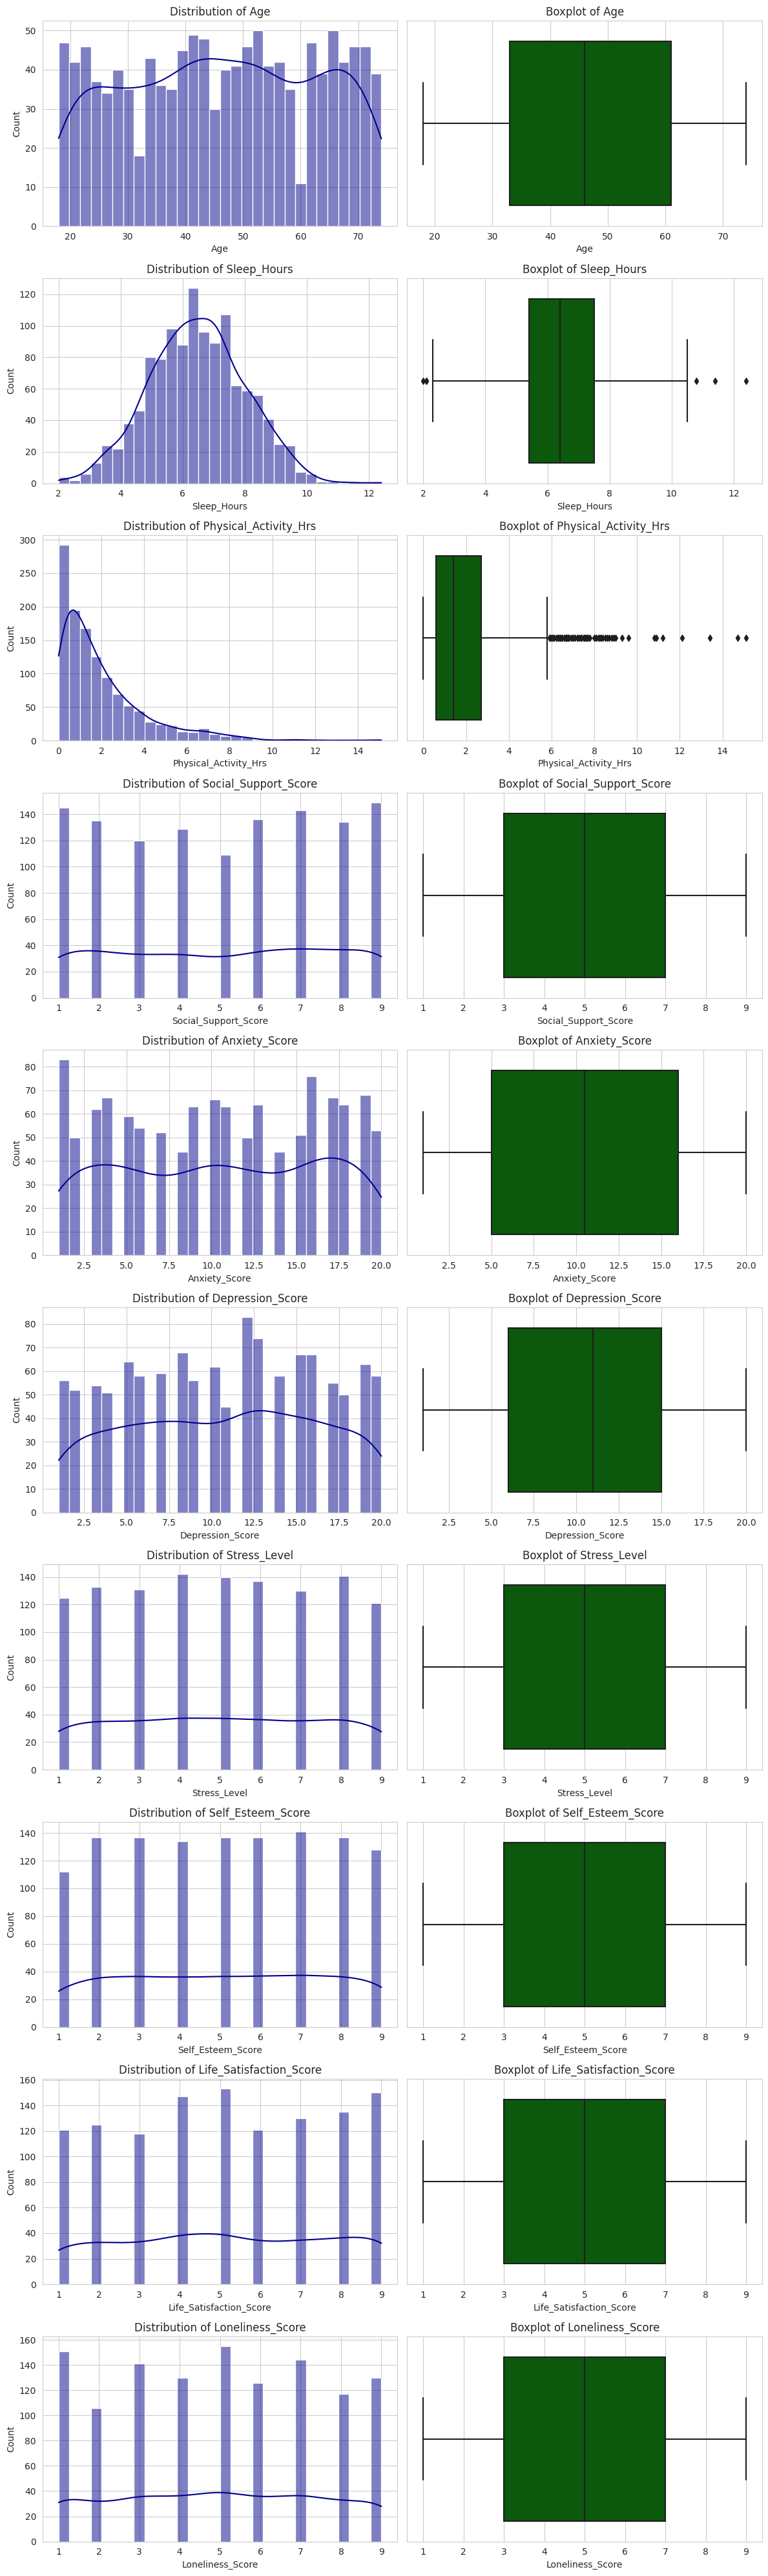

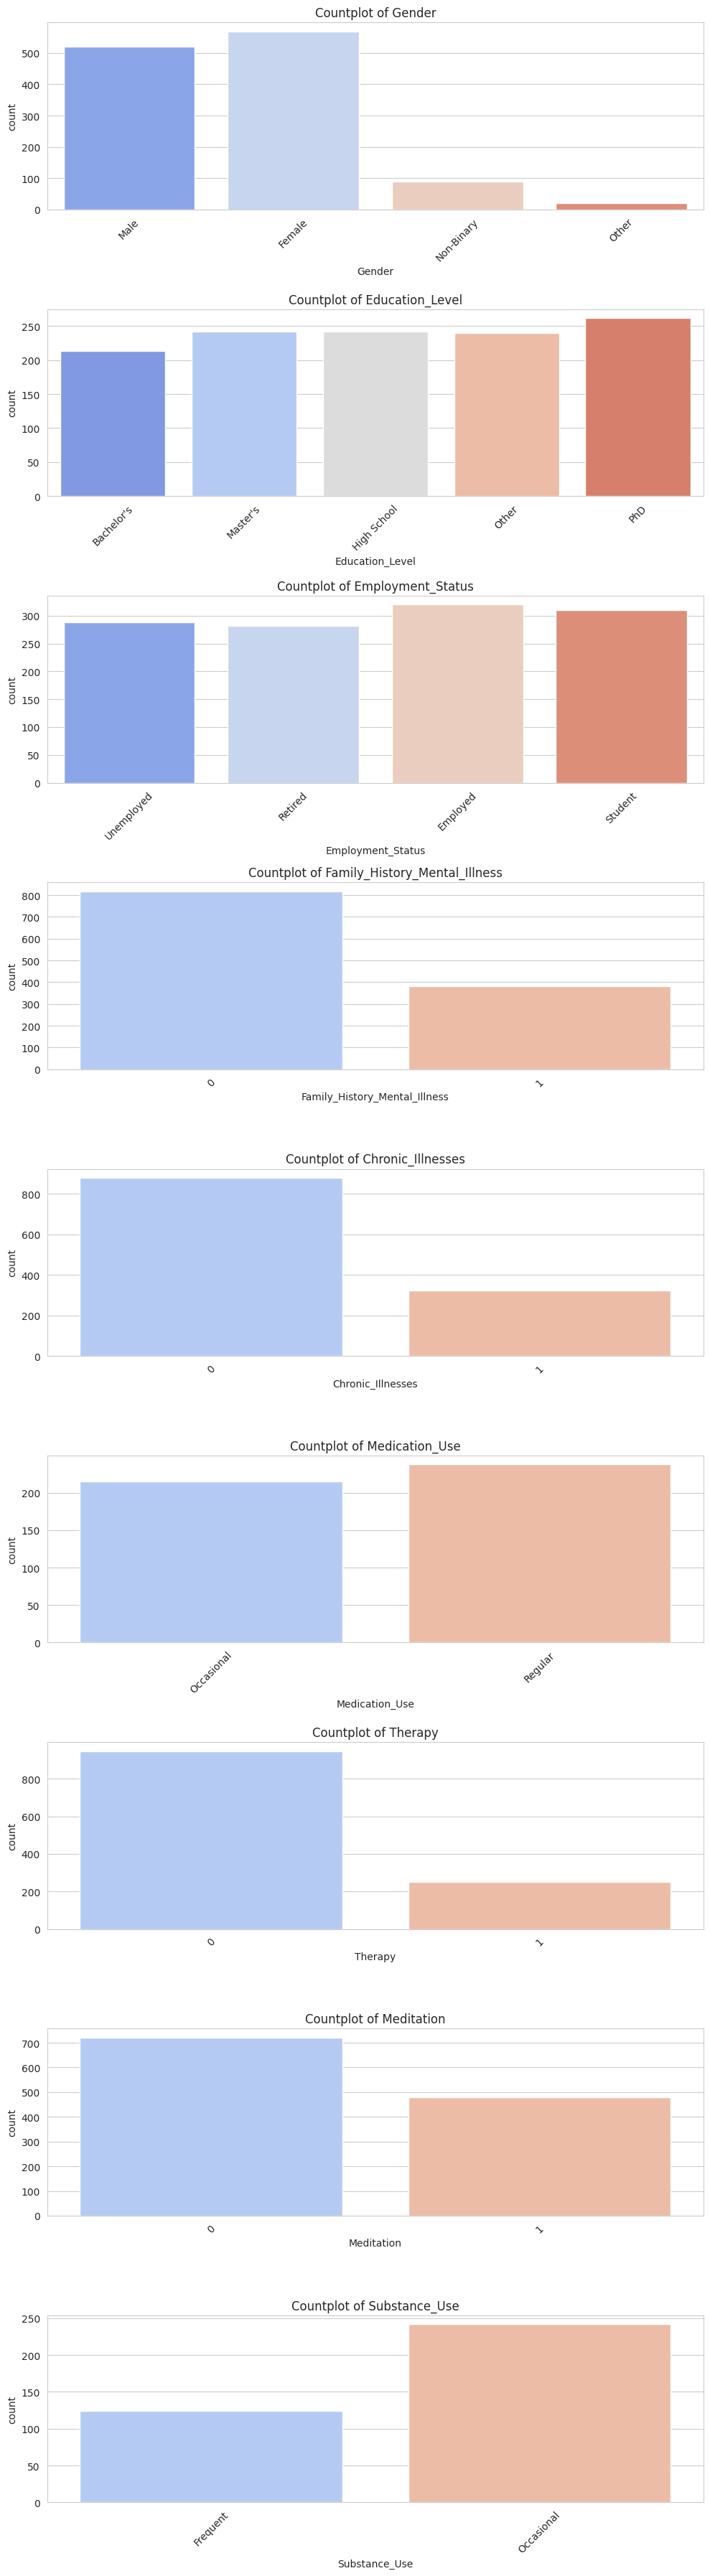

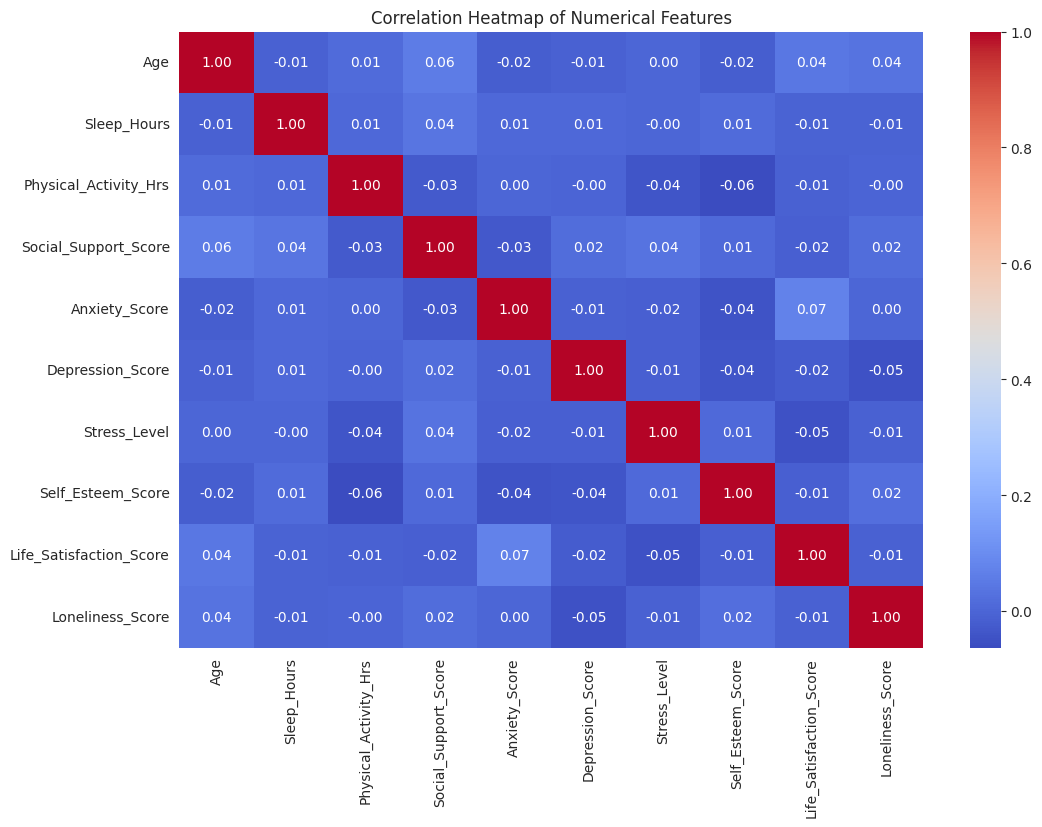

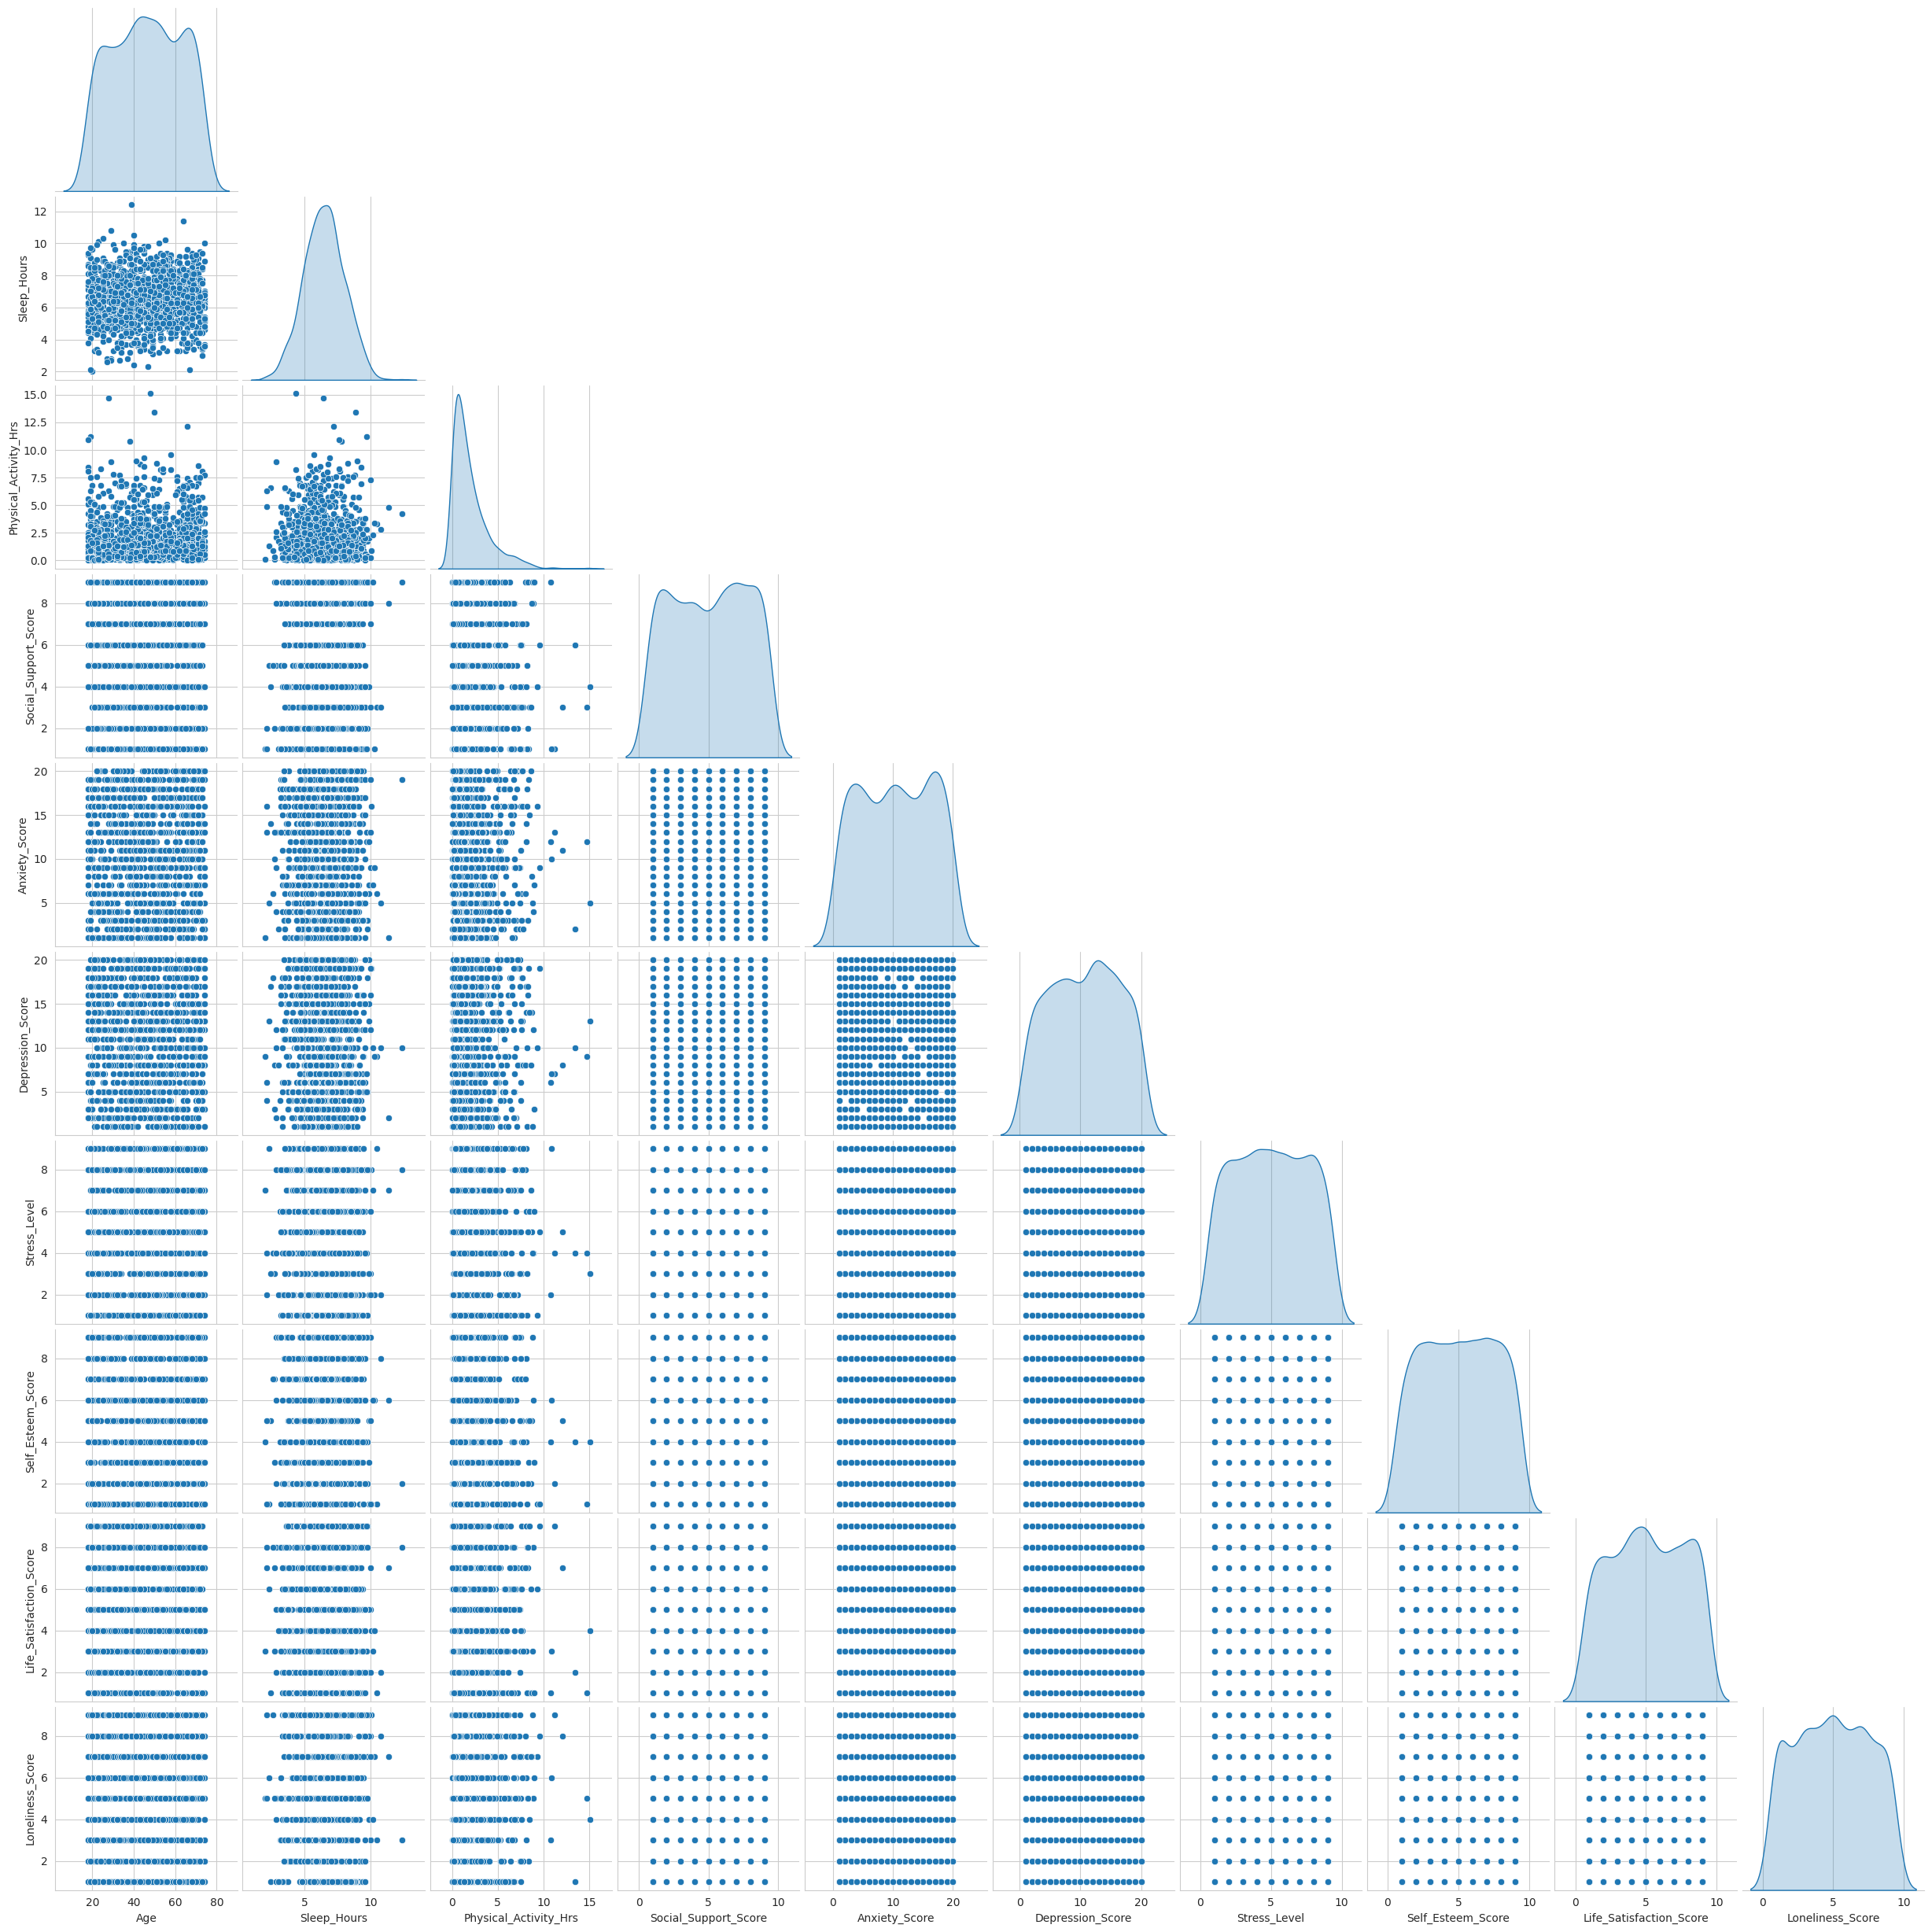

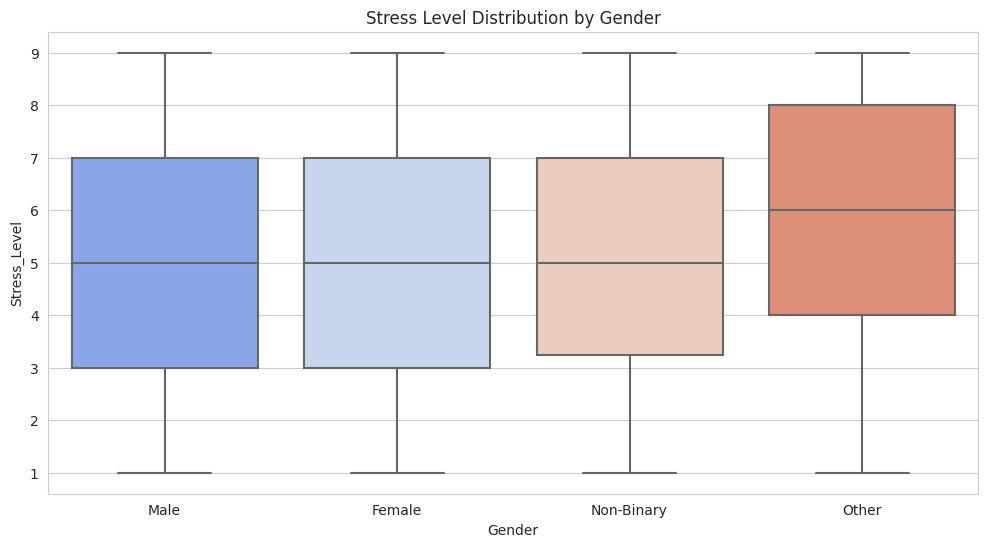

In [10]:
# Set style
sns.set_style("whitegrid")

# Define numerical and categorical columns
numerical_cols = ['Age', 'Sleep_Hours', 'Physical_Activity_Hrs', 'Social_Support_Score', 
                  'Anxiety_Score', 'Depression_Score', 'Stress_Level', 'Self_Esteem_Score', 
                  'Life_Satisfaction_Score', 'Loneliness_Score']
categorical_cols = ['Gender', 'Education_Level', 'Employment_Status', 'Family_History_Mental_Illness', 
                    'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation', 'Substance_Use']

# 1. Univariate Analysis
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, len(numerical_cols) * 4))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0], color='darkblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[i, 1], color='darkgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. Categorical Features Visualization
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Scatterplot Examples
sns.pairplot(df[numerical_cols], diag_kind='kde', corner=True)
plt.show()

# 5. Boxplot: Categorical vs. Numerical Example
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Gender'], y=df['Stress_Level'], palette='coolwarm')
plt.title('Stress Level Distribution by Gender')
plt.show()

## Predictive modeling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
# Set style
sns.set_style("whitegrid")

# Define numerical and categorical columns
numerical_cols = ['Age', 'Sleep_Hours', 'Physical_Activity_Hrs', 'Social_Support_Score', 
                  'Anxiety_Score', 'Depression_Score', 'Stress_Level', 'Self_Esteem_Score', 
                  'Life_Satisfaction_Score', 'Loneliness_Score']
categorical_cols = ['Gender', 'Education_Level', 'Employment_Status', 'Family_History_Mental_Illness', 
                    'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation', 'Substance_Use']

# Label Encoding for Categorical Variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [13]:
# Feature Selection
X = df[numerical_cols + categorical_cols]
y = df['Stress_Level']  # Assuming 'Stress_Level' is the target column

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize ML Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

# Train and Evaluate Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 0.7667
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        27
           2       0.89      0.81      0.85        21
           3       0.59      0.65      0.62        20
           4       0.61      0.58      0.59        33
           5       0.52      0.50      0.51        30
           6       0.69      0.71      0.70        31
           7       0.88      0.81      0.85        27
           8       0.88      0.92      0.90        24
           9       0.93      1.00      0.96        27

    accuracy                           0.77       240
   macro avg       0.77      0.78      0.77       240
weighted avg       0.77      0.77      0.77       240

--------------------------------------------------
Random Forest Accuracy: 0.9958
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        21
           3 

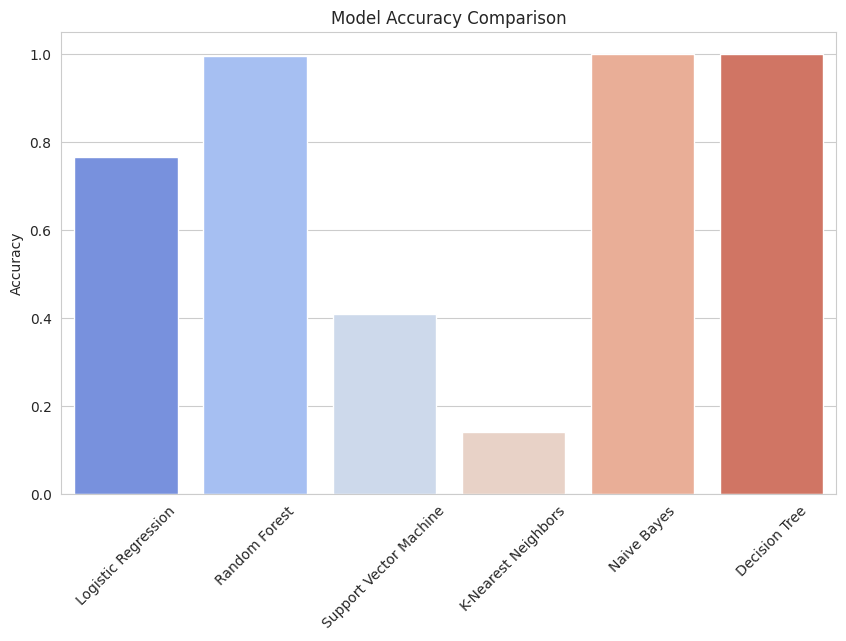

In [14]:
# Plot Accuracy Results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

## Thank you!!!...pls upvote!!!!